# **Customer Segmentation using Clustering Techniques**

Online retail is a transnational data set which contains all the transactions occurring between
01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.
The company mainly sells unique all-occasion gifts.
Many customers of the company are wholesalers.

##**Objective**

segement the Customers based on RFM so that the company can target its customers efficiently.

### R (Recency): Number of days since last purchase
### F (Frequency): Number of transactions
### M (Monetary): Total amount of transactions (revenue contributed)

In [1]:
# import required libraries for clustering
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
retail = pd.read_csv('OnlineRetail.csv', sep=",", encoding="ISO-8859-1", header=0)

In [3]:
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [4]:
# shape of df

retail.shape

(125128, 8)

In [5]:
# df info

retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125128 entries, 0 to 125127
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    125128 non-null  object 
 1   StockCode    125128 non-null  object 
 2   Description  124783 non-null  object 
 3   Quantity     125128 non-null  int64  
 4   InvoiceDate  125127 non-null  object 
 5   UnitPrice    125127 non-null  float64
 6   CustomerID   84296 non-null   float64
 7   Country      125127 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 7.6+ MB


# Data cleaning

In [6]:
# Calculating the Missing Values % contribution in DF

df_null = round(100*(retail.isnull().sum())/len(retail), 2)
df_null

,0
InvoiceNo,0.00
StockCode,0.00
Description,0.28
Quantity,0.00
InvoiceDate,0.00
UnitPrice,0.00
CustomerID,32.63
Country,0.00


In [7]:
# Droping rows having missing values

retail = retail.dropna()
retail.shape

(84296, 8)

In [8]:
# Changing the datatype of Customer Id

retail['CustomerID'] = retail['CustomerID'].astype(str)

In [9]:
# New Attribute : Monetary

retail['Amount'] = retail['Quantity']*retail['UnitPrice']
rfm_m = retail.groupby('CustomerID')['Amount'].sum()
rfm_m = rfm_m.reset_index()
rfm_m

,CustomerID,Amount
0,12346.0,0.00
1,12347.0,1187.18
2,12348.0,1120.24
3,12350.0,334.40
4,12352.0,561.18
...,...,...
2009,18269.0,138.90
2010,18270.0,111.95
2011,18277.0,-12.75
2012,18280.0,180.60


In [10]:
# New Attribute : Frequency

rfm_f = retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12346.0,2
1,12347.0,60
2,12348.0,23
3,12350.0,17
4,12352.0,33


In [11]:
# Merging the two dfs

rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346.0,0.00,2
1,12347.0,1187.18,60
2,12348.0,1120.24,23
3,12350.0,334.40,17
4,12352.0,561.18,33


In [12]:
# New Attribute : Recency

# Convert to datetime to proper datatype

retail['InvoiceDate'] = pd.to_datetime(retail['InvoiceDate'],format='%d-%m-%Y %H:%M')

In [13]:
# Compute the maximum date to know the last transaction date ## maximum = latest

max_date = max(retail['InvoiceDate'])
max_date

Timestamp('2011-03-18 15:43:00')

In [14]:
# Compute the difference between max date and transaction date

retail['Diff'] = max_date - retail['InvoiceDate']
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,107 days 07:17:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,107 days 07:17:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,107 days 07:17:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,107 days 07:17:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,107 days 07:17:00


In [15]:
# Compute recency of customer

rfm_p = retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,CustomerID,Diff
0,12346.0,59 days 05:26:00
1,12347.0,51 days 01:13:00
2,12348.0,52 days 05:01:00
3,12350.0,43 days 23:42:00
4,12352.0,0 days 23:43:00


In [16]:
# Extract number of days only

rfm_p['Diff'] = rfm_p['Diff'].dt.days
rfm_p.head()

,CustomerID,Diff
0,12346.0,59
1,12347.0,51
2,12348.0,52
3,12350.0,43
4,12352.0,0


In [17]:
# Merge the dataframes to get the final RFM dataframe

rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,0.00,2,59
1,12347.0,1187.18,60,51
2,12348.0,1120.24,23,52
3,12350.0,334.40,17,43
4,12352.0,561.18,33,0


Text(0.5, 0, 'Attributes')

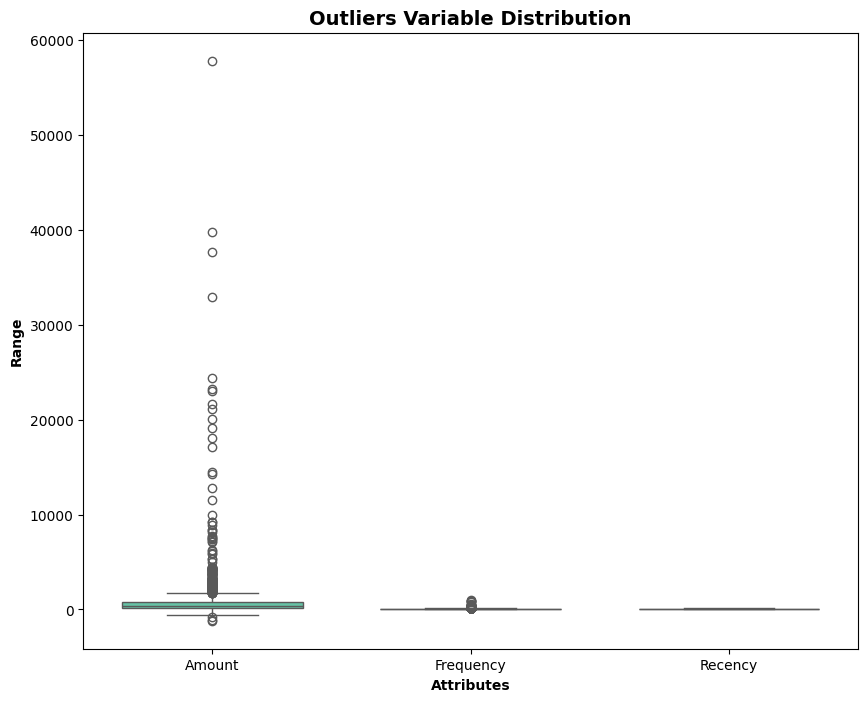

In [18]:
# Outlier Analysis of Amount Frequency and Recency

attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Outliers Variable Distribution", fontsize = 14, fontweight = 'bold')
plt.ylabel("Range", fontweight = 'bold')
plt.xlabel("Attributes", fontweight = 'bold')

In [19]:
# Removing (statistical) outliers for Amount
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5*IQR) & (rfm.Amount <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

# Removing (statistical) outliers for Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

# Scaling the features

In [20]:
rfm_df = rfm[['Amount', 'Frequency', 'Recency']]

# Instantiate
scaler = StandardScaler()

# fit_transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

(1978, 3)

In [21]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['Amount', 'Frequency', 'Recency']
rfm_df_scaled.head()

,Amount,Frequency,Recency
0,-0.824527,-0.843315,0.457744
1,0.730412,0.537071,0.222632
2,0.642736,-0.343520,0.252021
3,-0.386538,-0.486319,-0.012481
4,-0.089507,-0.105523,-1.276211


In [22]:
rfm_df_scaled

,Amount,Frequency,Recency
0,-0.824527,-0.843315,0.457744
1,0.730412,0.537071,0.222632
2,0.642736,-0.343520,0.252021
3,-0.386538,-0.486319,-0.012481
4,-0.089507,-0.105523,-1.276211
...,...,...,...
1973,-0.642599,-0.700517,1.427584
1974,-0.677898,-0.771916,-1.276211
1975,-0.841227,-0.867115,0.252021
1976,-0.587982,-0.652917,-0.952931


##**Model Building**

###**1.  K-Means Clustering**


In [23]:
# k-means with some arbitrary k

kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=4)

In [24]:
kmeans.labels_

array([2, 1, 0, ..., 0, 0, 1], dtype=int32)

In [25]:
set(kmeans.labels_)

{np.int32(0), np.int32(1), np.int32(2), np.int32(3)}

# Elbow Curve to get the right number of Clusters

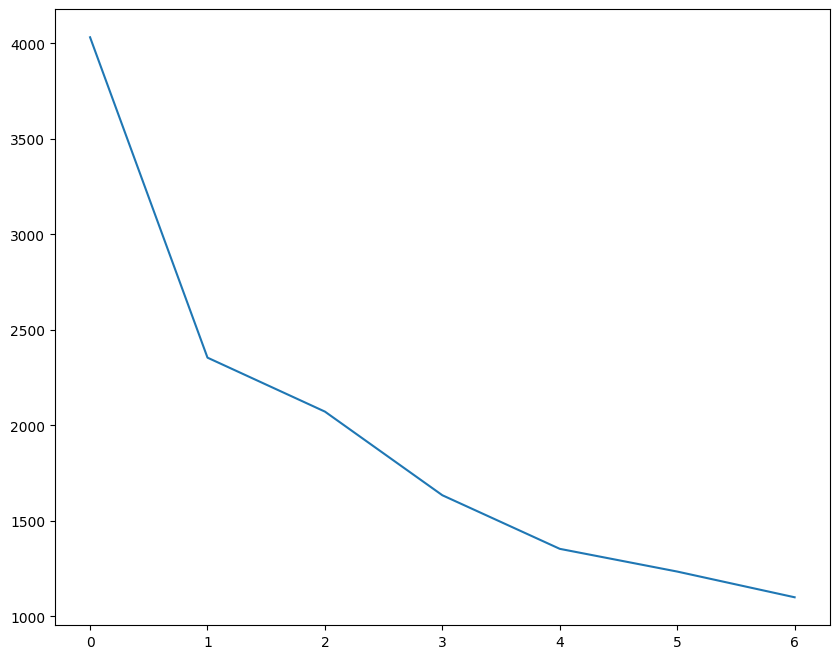

In [26]:
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(rfm_df_scaled)

    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
plt.plot(ssd)

In [27]:
# Final model with k=3
kmeans = KMeans(n_clusters=3, max_iter=50)
kmeans.fit(rfm_df_scaled)

KMeans(max_iter=50, n_clusters=3)

In [28]:
 kmeans.labels_

array([0, 2, 2, ..., 2, 2, 1], dtype=int32)

In [29]:
# assign the label
rfm['Cluster_Id'] = kmeans.labels_
rfm.head()

,CustomerID,Amount,Frequency,Recency,Cluster_Id
0,12346.0,0.00,2,59,0
1,12347.0,1187.18,60,51,2
2,12348.0,1120.24,23,52,2
3,12350.0,334.40,17,43,2
4,12352.0,561.18,33,0,2


<Axes: xlabel='Cluster_Id', ylabel='Amount'>

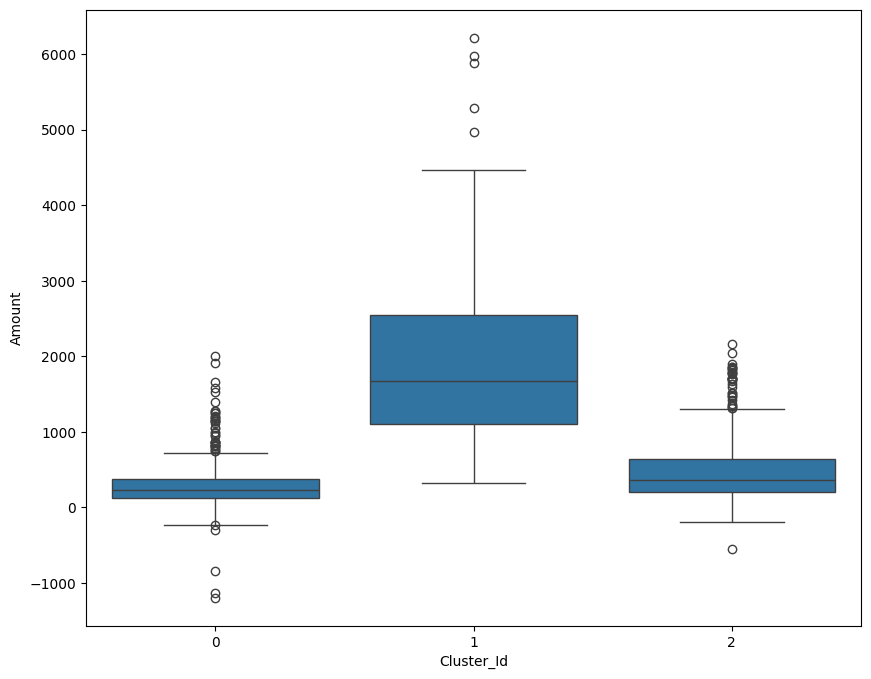

In [30]:
# Box plot to visualize Cluster Id vs Amount

sns.boxplot(x='Cluster_Id', y='Amount', data=rfm)

<Axes: xlabel='Cluster_Id', ylabel='Frequency'>

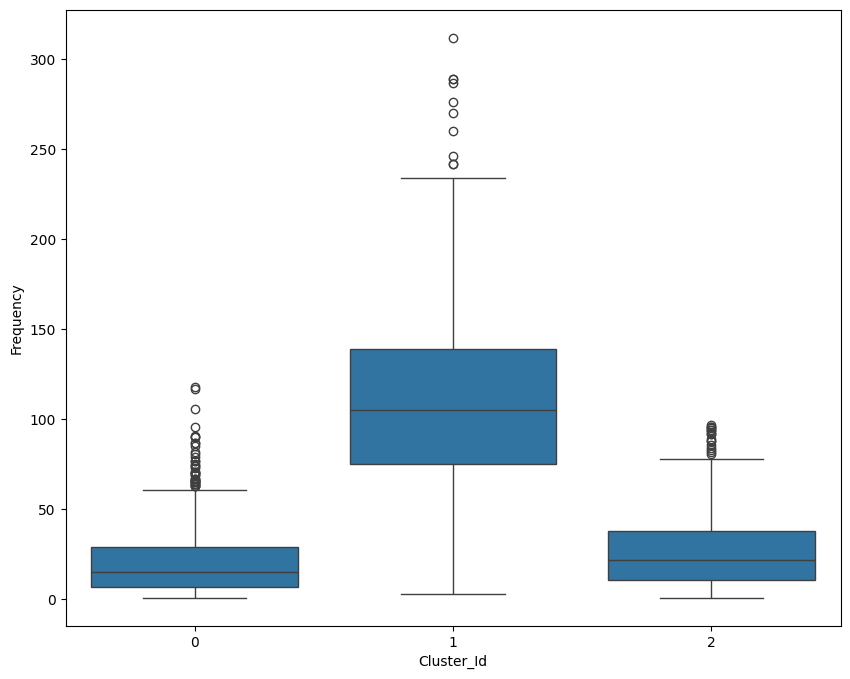

In [31]:
# Box plot to visualize Cluster Id vs Frequency

sns.boxplot(x='Cluster_Id', y='Frequency', data=rfm)

<Axes: xlabel='Cluster_Id', ylabel='Recency'>

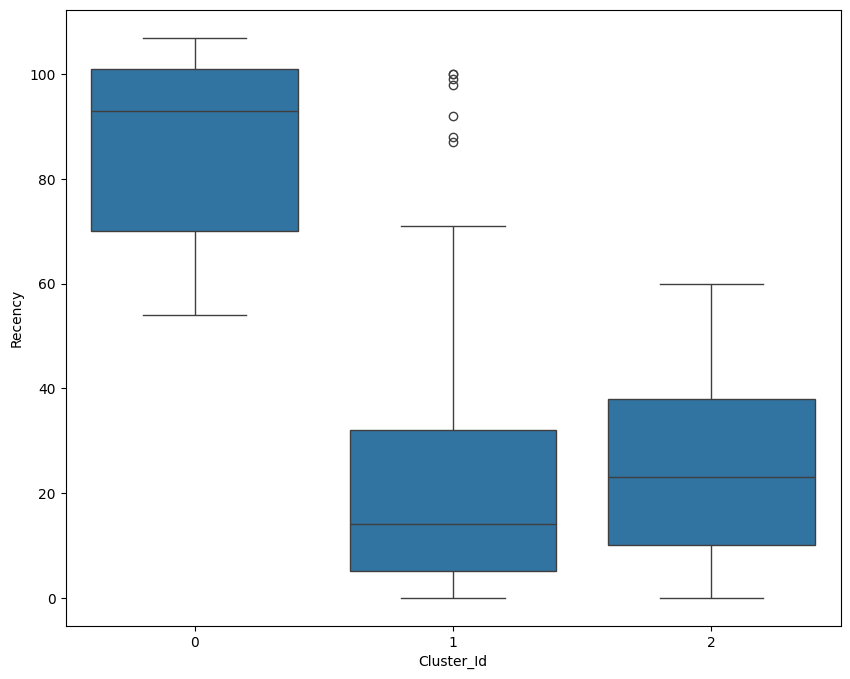

In [32]:
# Box plot to visualize Cluster Id vs Recency

sns.boxplot(x='Cluster_Id', y='Recency', data=rfm)

###**2.Hierarchial Clustering**

In [33]:
from sklearn.cluster import AgglomerativeClustering

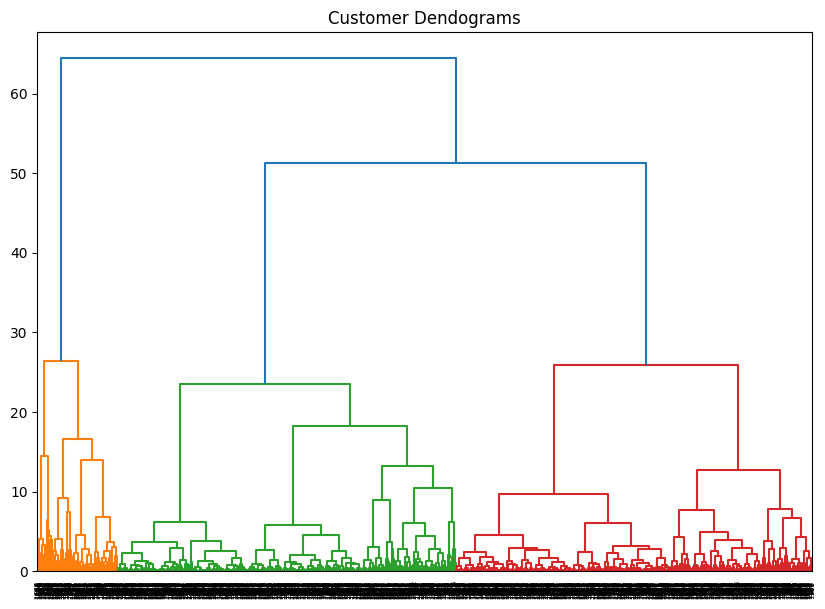

In [34]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))
plt.title("Customer Dendograms")
dend = shc.dendrogram(shc.linkage(rfm_df_scaled, method='ward'))

##From the dendogram , we can see that if a horizontal line is drawn through the longest vertical line , it can cut 3 such vertical lines which means 3 clusters should be ideal.

In [35]:
model1 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
labels_ = model1.fit_predict(rfm_df_scaled)

In [36]:
labels_

array([2, 2, 2, ..., 2, 1, 0])

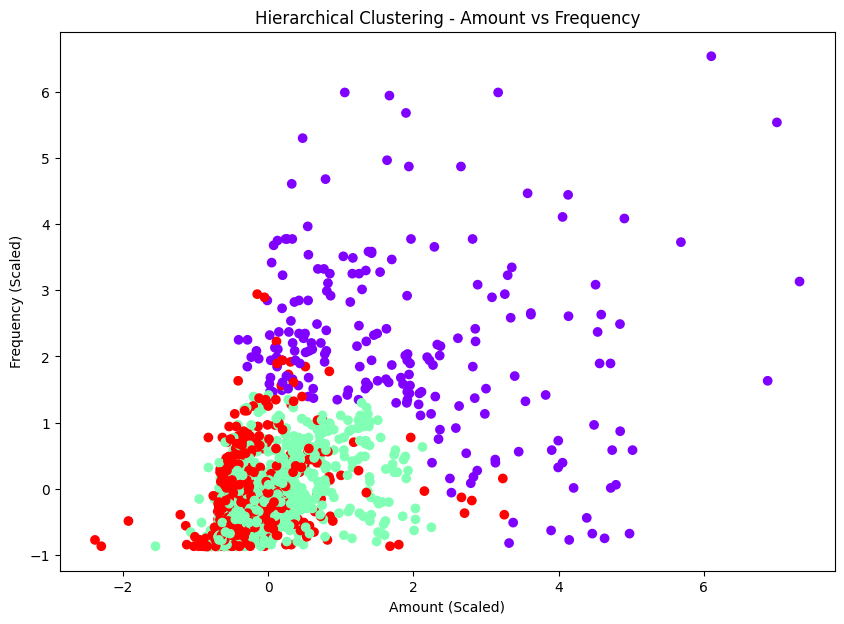

In [37]:
plt.figure(figsize=(10,7))
plt.scatter(rfm_df_scaled['Amount'], rfm_df_scaled['Frequency'], c=model1.labels_, cmap='rainbow')
plt.xlabel('Amount (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('Hierarchical Clustering - Amount vs Frequency')
plt.show()

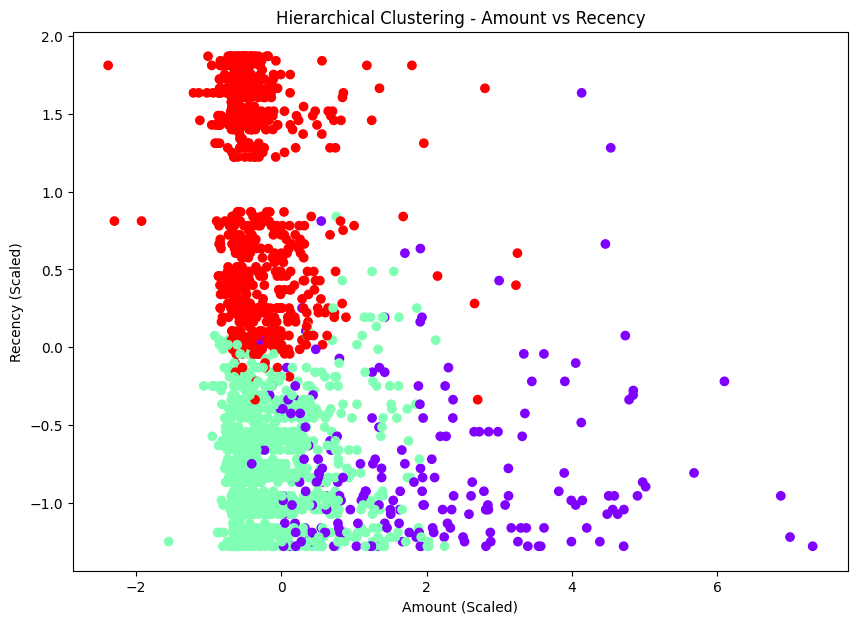

In [38]:
plt.figure(figsize=(10,7))
plt.scatter(rfm_df_scaled['Amount'], rfm_df_scaled['Recency'], c=model1.labels_, cmap='rainbow')
plt.xlabel('Amount (Scaled)')
plt.ylabel('Recency (Scaled)')
plt.title('Hierarchical Clustering - Amount vs Recency')
plt.show()

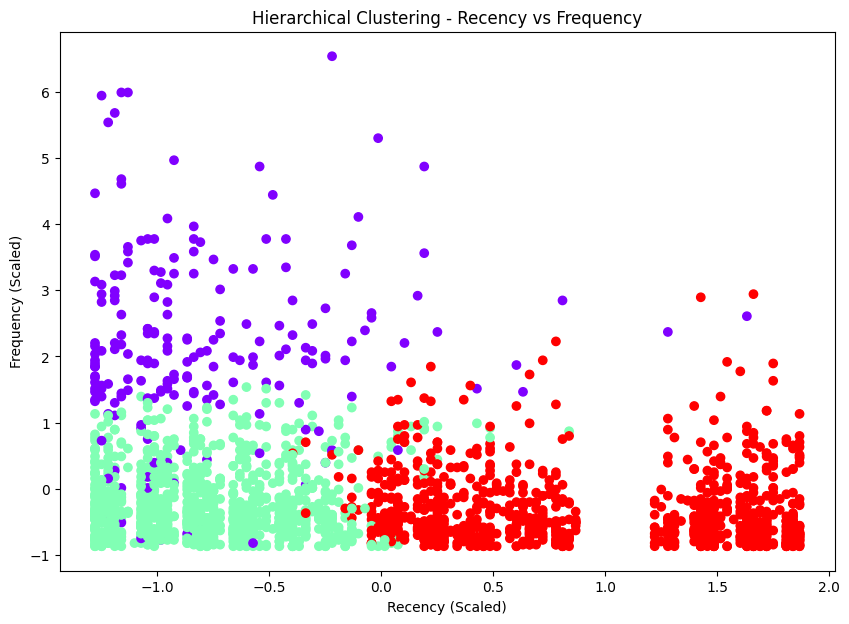

In [39]:
plt.figure(figsize=(10,7))
plt.scatter(rfm_df_scaled['Recency'], rfm_df_scaled['Frequency'], c=model1.labels_, cmap='rainbow')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Frequency (Scaled)')
plt.title('Hierarchical Clustering - Recency vs Frequency')
plt.show()

##**3.DBSCAN**

In [40]:
from sklearn.cluster import DBSCAN

In [41]:
model2 = DBSCAN(eps=1 , min_samples=3)
model2.fit(rfm_df_scaled)

DBSCAN(eps=1, min_samples=3)

In [42]:
np.unique(model2.labels_)

array([-1,  0,  1])

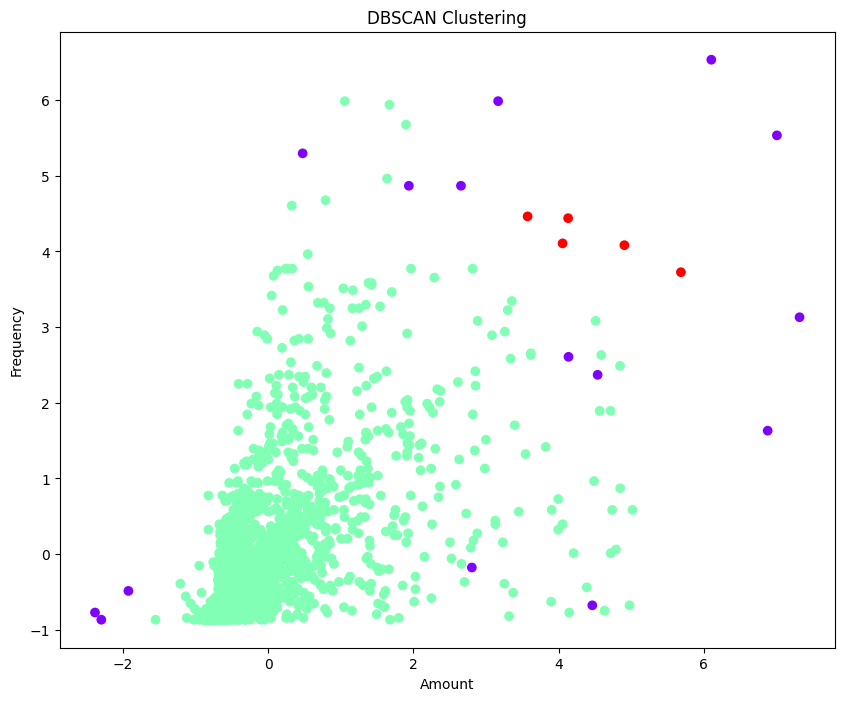

In [43]:
plt.scatter(rfm_df_scaled['Amount'],rfm_df_scaled['Frequency'] , c=model2.labels_, cmap='rainbow')
plt.title('DBSCAN Clustering')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

In [44]:
from sklearn.metrics import silhouette_score
eps_values =  [0.5,0.6,0.7,0.8,0.9,1]
min_samples_values = [1,2,3,4,5,6]

best_score = -1

for eps in eps_values:
    for ms in min_samples_values:

        db = DBSCAN(eps=eps,
                    min_samples=ms)

        labels = db.fit_predict(rfm_df_scaled)

        # Ignore solutions with only one cluster
        if len(set(labels)) <= 1:
            continue

        score = silhouette_score(rfm_df_scaled, labels)

        if score > best_score:
            best_score = score
            best_eps = eps
            best_ms = ms

In [45]:
best_score , best_eps , best_ms

(np.float64(0.6446869844836559), 1, 5)

In [46]:
model3 = DBSCAN(eps=best_eps , min_samples=best_ms)
model3.fit(rfm_df_scaled)

DBSCAN(eps=1)

In [47]:
np.unique(model3.labels_)

array([-1,  0])

In [48]:
rfm_df.iloc[model3.labels_ == -1]

,Amount,Frequency,Recency
30,4969.22,194,16
33,3787.12,147,99
44,6216.68,169,0
59,-1126.00,1,71
78,4037.12,9,66
127,5978.61,270,2
313,2108.27,242,50
380,5881.44,106,11
637,-1192.20,5,105
748,1903.86,287,1


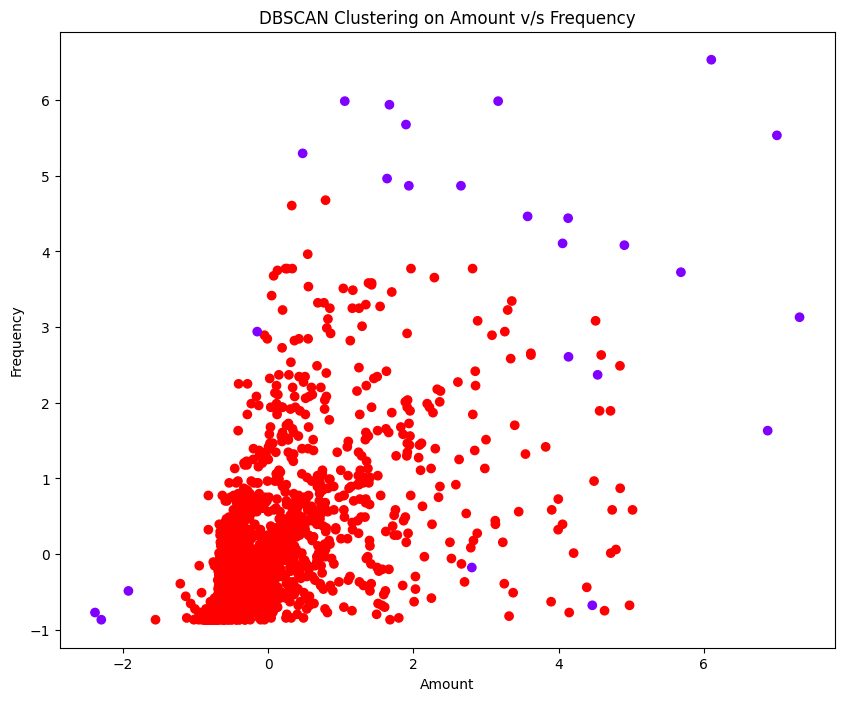

In [49]:
plt.scatter(rfm_df_scaled['Amount'],rfm_df_scaled['Frequency'] , c=model3.labels_, cmap='rainbow')
plt.title('DBSCAN Clustering on Amount v/s Frequency')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

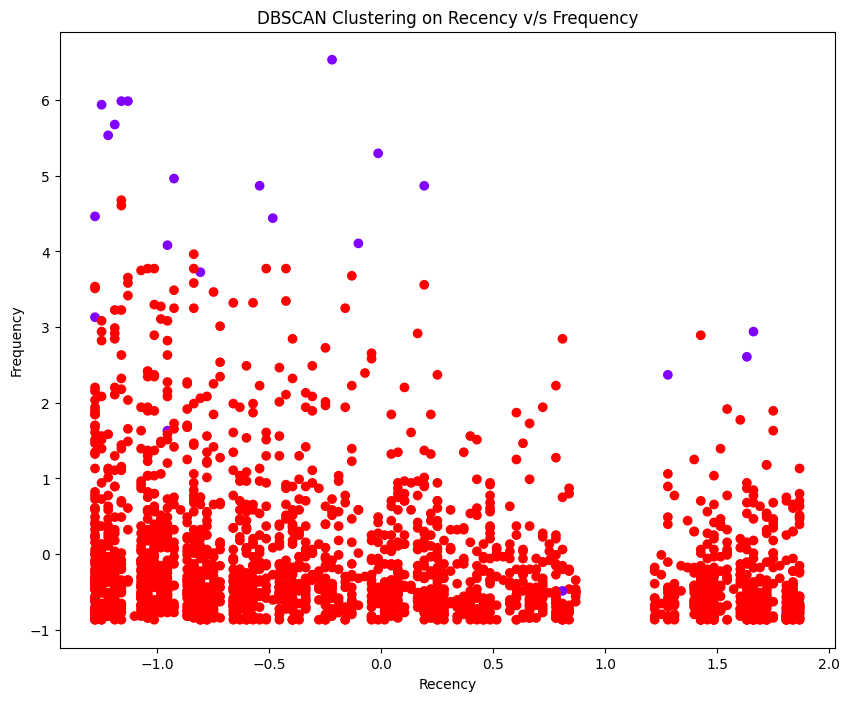

In [50]:
plt.scatter(rfm_df_scaled['Recency'],rfm_df_scaled['Frequency'] , c=model3.labels_, cmap='rainbow')
plt.title('DBSCAN Clustering on Recency v/s Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.show()

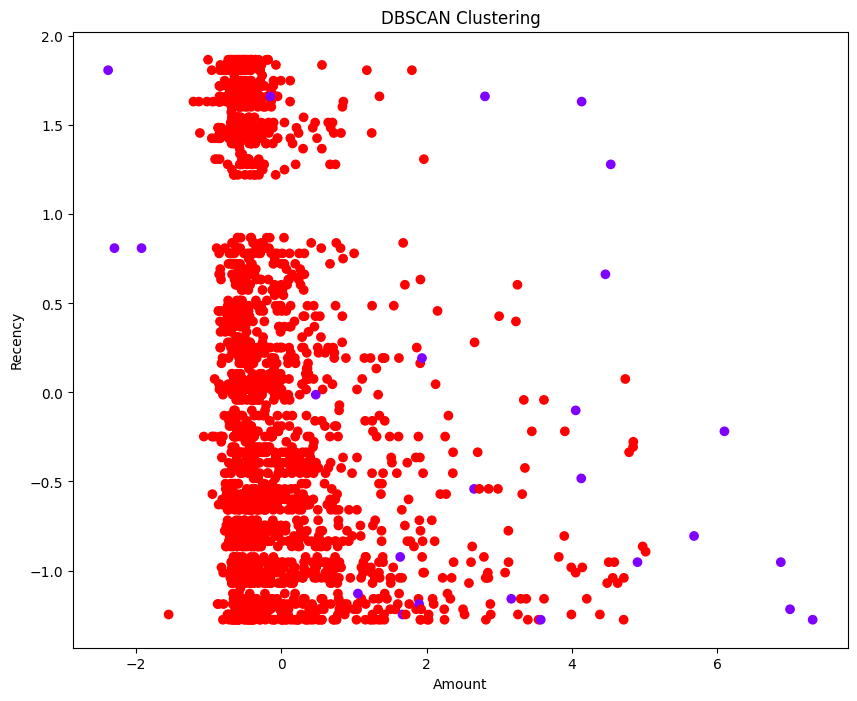

In [51]:
plt.scatter(rfm_df_scaled['Amount'],rfm_df_scaled['Recency'] , c=model3.labels_, cmap='rainbow')
plt.title('DBSCAN Clustering')
plt.xlabel('Amount')
plt.ylabel('Recency')
plt.show()

##**4.Gaussian Mixture Model**

In [52]:
from sklearn.mixture import GaussianMixture

In [53]:
model4 = GaussianMixture(n_components=3)
labels = model4.fit_predict(rfm_df_scaled)

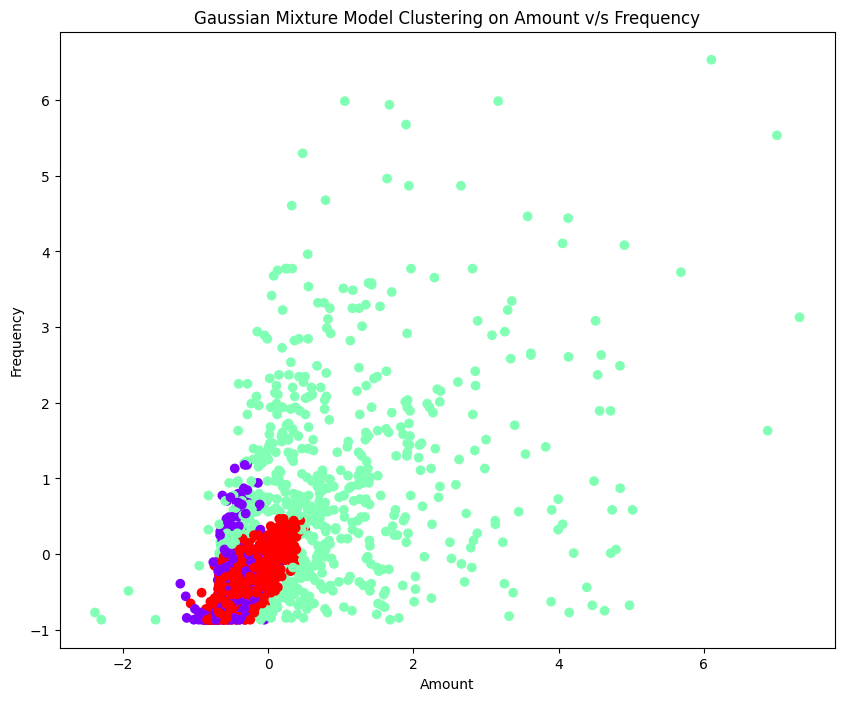

In [54]:
plt.scatter(rfm_df_scaled['Amount'],rfm_df_scaled['Frequency'] , c=labels, cmap='rainbow')
plt.title('Gaussian Mixture Model Clustering on Amount v/s Frequency')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

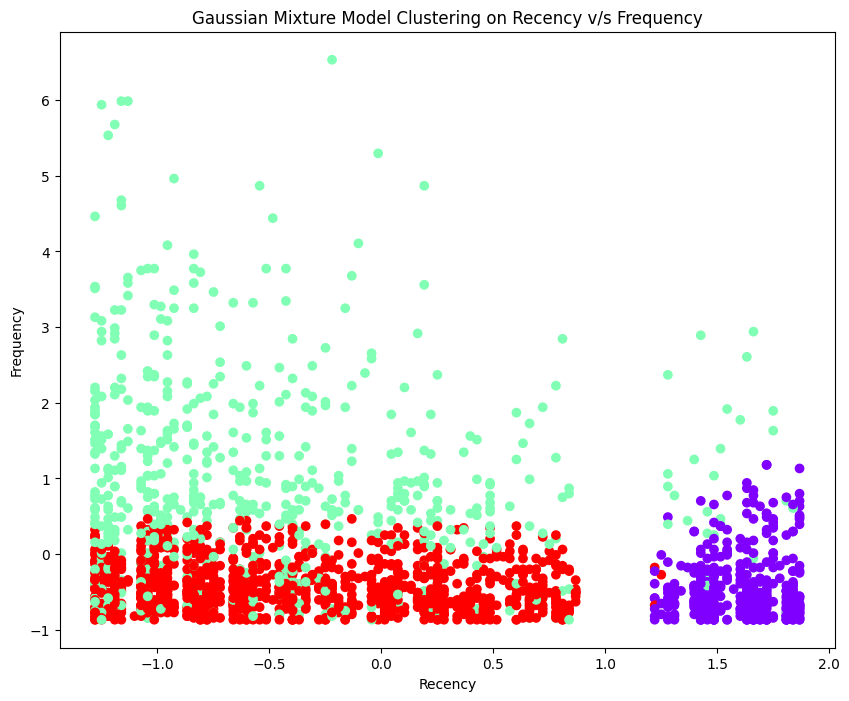

In [55]:
plt.scatter(rfm_df_scaled['Recency'],rfm_df_scaled['Frequency'] , c=labels, cmap='rainbow')
plt.title('Gaussian Mixture Model Clustering on Recency v/s Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.show()

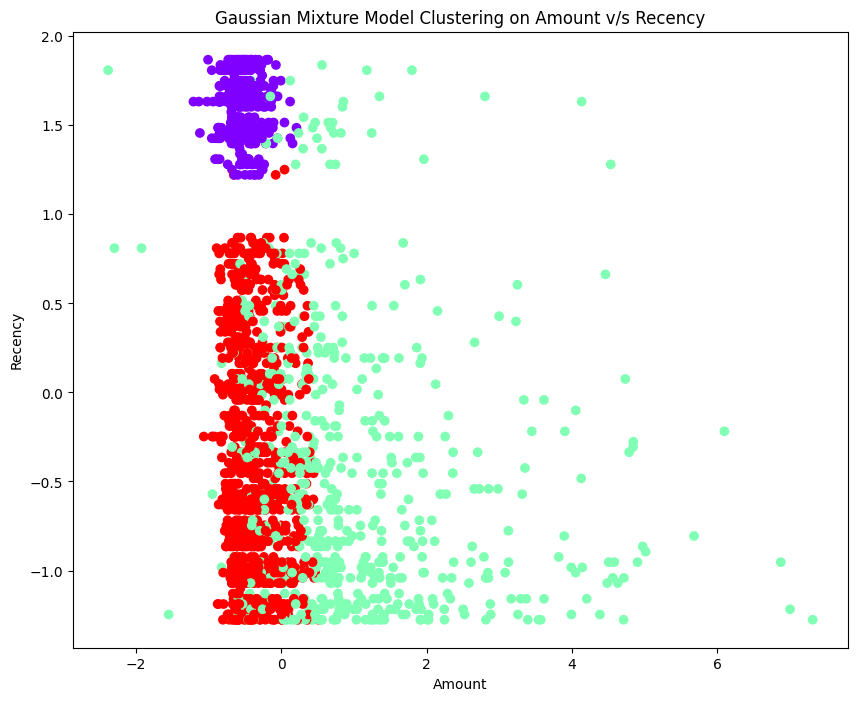

In [56]:
plt.scatter(rfm_df_scaled['Amount'],rfm_df_scaled['Recency'] , c=labels, cmap='rainbow')
plt.title('Gaussian Mixture Model Clustering on Amount v/s Recency')
plt.xlabel('Amount')
plt.ylabel('Recency')
plt.show()

##**Conclusion**
